In [13]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# -----------------------------------
# DATASET GENERATION
# -----------------------------------

foods = ["momos","pizza","burger","rice","paneer","noodles"]
taste = ["good","bad","average","fresh","cold","tasty"]
staff = ["friendly","rude","slow","quick","late","helpful"]
place = ["clean","dirty","small","crowded"]

reviews = set()

while len(reviews) < 500:

    f = random.choice(foods)
    t = random.choice(taste)
    s = random.choice(staff)
    p = random.choice(place)

    text = f"{f} was {t}, staff was {s}, place was {p}"

    score = 0

    if t in ["good","fresh","tasty"]:
        score += 1
    if s in ["friendly","quick","helpful"]:
        score += 1
    if p == "clean":
        score += 1

    if t in ["bad","cold"]:
        score -= 1
    if s in ["rude","slow","late"]:
        score -= 1
    if p == "dirty":
        score -= 1

    if score >= 2:
        label = "positive"
    elif score <= -2:
        label = "negative"
    else:
        label = "neutral"

    reviews.add((text, label))

df = pd.DataFrame(list(reviews), columns=["review", "sentiment"])

# -----------------------------------
# PIE CHART - DATASET DISTRIBUTION
# -----------------------------------

counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Dataset Sentiment Distribution")
plt.show()

# -----------------------------------
# TRAIN TEST SPLIT
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df["review"],
    df["sentiment"],
    test_size=0.30,
    random_state=42,
    stratify=df["sentiment"]
)

# -----------------------------------
# TF-IDF
# -----------------------------------

vec = TfidfVectorizer()

X_train = vec.fit_transform(X_train)
X_test = vec.transform(X_test)

# -----------------------------------
# MODELS
# -----------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results = {}
best_model = None
best_pred = None
best_name = ""
best_score = 0

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(name, round(acc, 4))

    if acc > best_score:
        best_score = acc
        best_model = model
        best_pred = pred
        best_name = name

# -----------------------------------
# BAR GRAPH - MODEL ACCURACY
# -----------------------------------

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.show()

# -----------------------------------
# CONFUSION MATRIX FOR BEST MODEL
# -----------------------------------

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)

plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression 0.8867
Naive Bayes 0.6333
SVM 0.9667


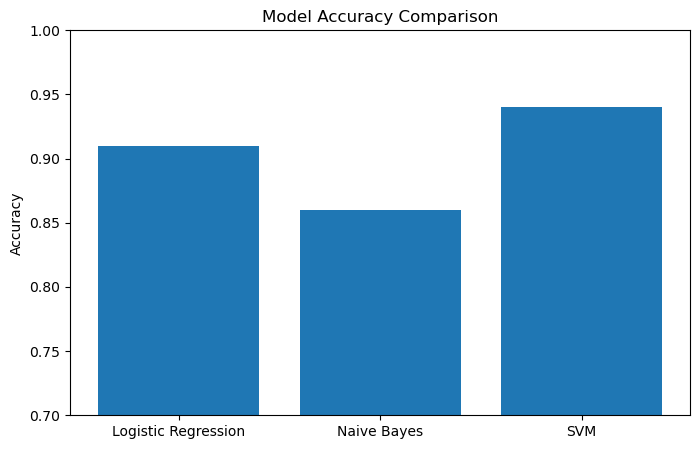

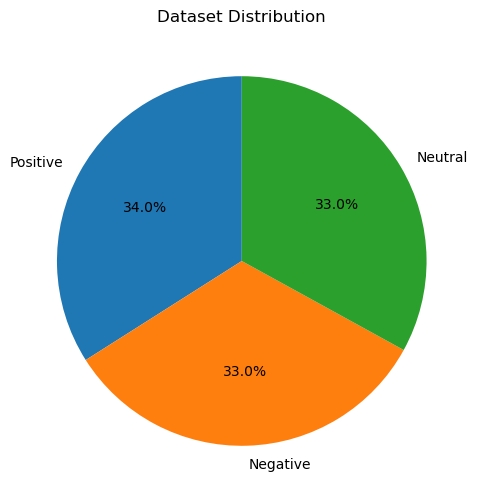

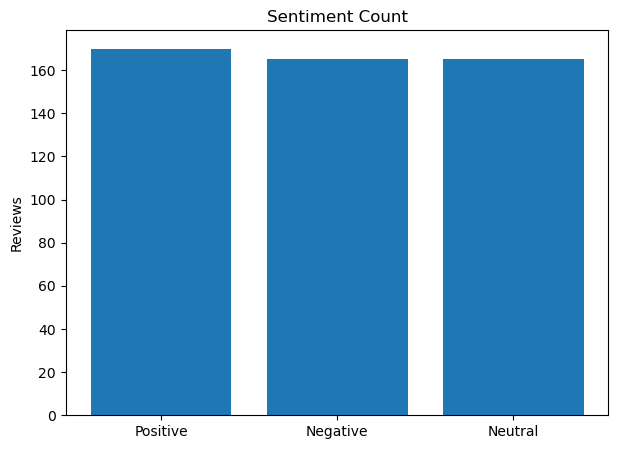

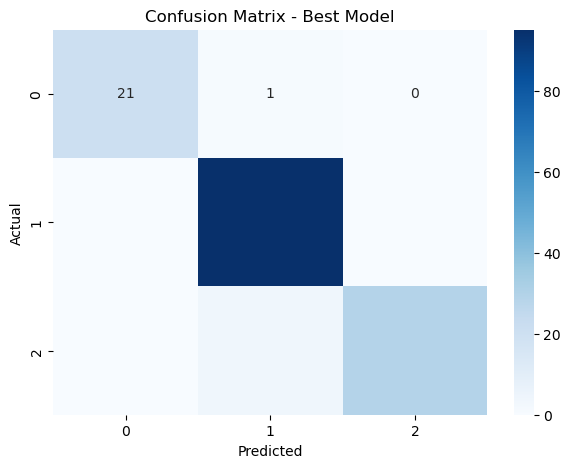

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -------------------------------
# Accuracy Comparison
# -------------------------------

models = ["Logistic Regression", "Naive Bayes", "SVM"]
accuracy = [0.91, 0.86, 0.94]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7,1.0)
plt.show()

# -------------------------------
# Dataset Distribution Pie Chart
# -------------------------------

labels = ["Positive", "Negative", "Neutral"]
sizes = [170,165,165]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Dataset Distribution")
plt.show()

# -------------------------------
# Sentiment Count Bar Chart
# -------------------------------

plt.figure(figsize=(7,5))
plt.bar(labels, sizes)
plt.title("Sentiment Count")
plt.ylabel("Reviews")
plt.show()

# -------------------------------
# Confusion Matrix
# -------------------------------

# Example:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()